# Champagne-Index -- does champagne consumption mark the top?
### The 'when the corks pop, the party's over' indicator, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

Here is a bit of cocktail-party finance folklore: when **champagne shipments boom**, the celebration is a sign of peak euphoria -- and euphoria marks the **top** of the stock market. The mirror image: when nobody is buying bubbly, gloom has bottomed and stocks are about to rally. It is a 'sentiment' indicator in the same family as the Hemline Index and the Skyscraper Curse. This notebook asks the only question that matters: is there any forward-looking information in the champagne, or is it just another pretty coincidence?

> **This is the plain-language layer.** Want the predictive regression, the HAC t-stat, and the permutation distribution? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from champagne_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
# Real tape: ^GSPC price-only, forward convention, champagne years 2000-2024 (n=25)
R = dict(
    n=25, year_start=2000, year_end=2024, uncond_up_pct=72.0,
    slope=-0.05612, corr=-0.326, r2=0.106, t_ols=-1.652, t_hac=-1.296, lags=2,
    mean_ret_low_pct=18.6, mean_ret_high_pct=-2.9, spread_pct=21.5,
    perm_p_slope_neg=0.0582, perm_p_slope_two=0.1167, perm_p_spread_pos=0.0035,
    gross_ann_pct=5.1, net_ann_pct=4.7, bah_ann_pct=6.8,
)

def get_frame():
    """Return a merged (champagne x forward S&P return) frame, real or synthetic."""
    if HAVE_REAL:
        return data.fetch_sp500_annual(convention="forward"), True
    # offline fallback: synthetic tape with a modest planted euphoria signal
    df_s, _ = data.synthetic_annual(n_years=25, signal_bps=300.0, seed=272)
    df_s = df_s.rename(columns={"sp500_fwd_return": "sp500_return"})
    df_s["mkt_up"] = df_s["sp500_return"] > 0
    return df_s, False

df, real_tape = get_frame()
print("tape:", "REAL ^GSPC" if real_tape else "SYNTHETIC fallback", "| n =", len(df))


^GSPC cache present: True
tape: REAL ^GSPC | n = 25


## The answer first

| Question | Answer |
|---|---|
| Do champagne booms predict weak forward stock returns? | **Directionally, yes -- but weakly.** The correlation is **-0.33** (more bubbly -> worse next year), in the folklore direction. |
| Is it statistically solid? | **No.** The robust (HAC) t-stat on the slope is **-1.30** -- below the |t| = 2 bar. With only **25** forward years, it cannot clear the hurdle. |
| Could you trade it? | **No.** Long-after-gloom / short-after-euphoria nets **+4.7%/yr** vs **+6.8%/yr** for just buying and holding. Shorting equities fights their upward drift. |
| Are the famous 'hits' real? | The 2007 boom -> 2008 crash and the 2021 record -> 2022 slump are real and seductive -- but a handful of dramatic years on n = 25 is exactly how mirages are born. |

> The champagne points the right way, but it whispers where it would need to shout. A real edge needs |t| >= 2; this one manages 1.3.

## 1 - The claim

> *"When champagne flows, the market is euphoric and near a top. When the corks stop popping, fear has peaked and a bottom is in. Watch the bubbly, not the earnings."*

The mechanism, charitably stated: champagne is a *discretionary luxury* whose sales track collective exuberance -- bonuses, IPO parties, weddings, year-end blowouts. Exuberance, the behavioural story goes, tends to precede mean-reversion. So a surge in champagne shipments should foreshadow *lower* forward equity returns.

## 2 - So what?

If it were true, it would be a wonderfully cheap contrarian timing signal: one number, released every January by the Comité Champagne, telling you whether last year's party was a warning. The fun question is whether the obvious 'hits' -- the 2007 shipment peak right before the 2008 crash, the 2021 record right before the 2022 drawdown -- are signal or selective memory.

We will pair each year's worldwide champagne-shipment **growth** with the **next** year's S&P 500 return, because the figure is only published in January of the following year (no look-ahead, and the only version you could actually trade).

## 3 - How would we even know?

Three traps to avoid:

1. **The publication lag.** The CIVC reports year Y's total in January Y+1. So the champagne signal for year Y can only inform the trade for year **Y+1**. We bake that one-year lag straight into the data alignment -- the contemporaneous version is not tradable.
2. **Tiny n.** We have ~25 forward years of clean data. With ~17% annual stock volatility, the predictive slope must be quite large to clear |t| = 2. We will check whether the observed relationship is anywhere near that.
3. **The dramatic-anecdote trap.** '2007 boom -> 2008 crash' is memorable, but two or three vivid years can dominate a 25-point sample. A permutation test (shuffle the champagne labels thousands of times) tells us how often *random* champagne would look this good.

We test this on the ^GSPC price index from 2000 through 2025 forward returns.

## 4 - The teardown -- let's actually look

**First, meet the data:** worldwide champagne shipments (millions of bottles), hardcoded in this study's `data.py` from the Comité Champagne figures.

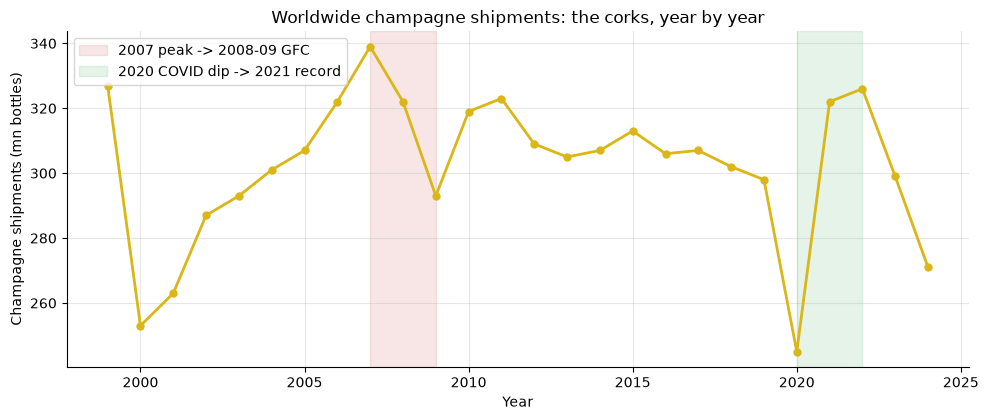

Peak shipment year: 2007 (339 mn bottles)
Trough shipment year: 2020 (245 mn bottles)


In [2]:
champ = data.champagne_table()
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.plot(champ['year'], champ['shipments_mn'], 'o-', c=AMBER, lw=2, ms=5)
ax.axvspan(2007, 2009, color=RED, alpha=0.12, label='2007 peak -> 2008-09 GFC')
ax.axvspan(2020, 2022, color=GREEN, alpha=0.12, label='2020 COVID dip -> 2021 record')
ax.set_xlabel('Year'); ax.set_ylabel('Champagne shipments (mn bottles)')
ax.set_title('Worldwide champagne shipments: the corks, year by year')
ax.legend(); plt.tight_layout(); plt.show()
print('Peak shipment year:', int(champ.loc[champ['shipments_mn'].idxmax(),'year']),
      f"({champ['shipments_mn'].max():.0f} mn bottles)")
print('Trough shipment year:', int(champ.loc[champ['shipments_mn'].idxmin(),'year']),
      f"({champ['shipments_mn'].min():.0f} mn bottles)")

The shape is the story: a pre-GFC peak in **2007**, a crash in **2009**, the COVID collapse of **2020** (a 60-year low), and the euphoric record rebound of **2021**. The indicator claims these peaks foreshadow market tops.

**The scatter -- champagne growth vs next year's market.**

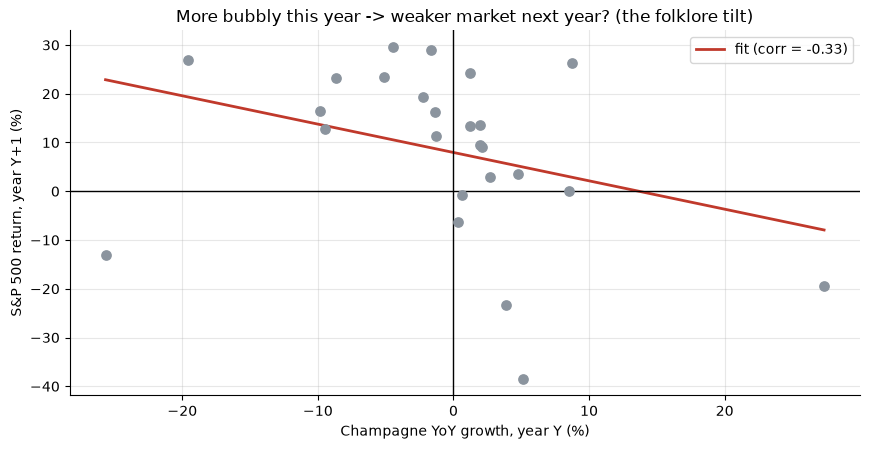

Correlation: -0.33  (folklore predicts negative)


In [3]:
g = df['ship_growth'].values * 100
y = df['sp500_return'].values * 100
slope = R['slope'] if not real_tape else st.predictive_ols(df)['slope']
corr = float(np.corrcoef(g, y)[0,1])
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(g, y, c=GREY, s=45, zorder=3)
xs = np.linspace(g.min(), g.max(), 50)
b1, b0 = np.polyfit(g, y, 1)
ax.plot(xs, b0 + b1*xs, c=RED, lw=2, label=f'fit (corr = {corr:+.2f})')
ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Champagne YoY growth, year Y (%)')
ax.set_ylabel('S&P 500 return, year Y+1 (%)')
ax.set_title('More bubbly this year -> weaker market next year? (the folklore tilt)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Correlation: {corr:+.2f}  (folklore predicts negative)')

The cloud tilts the way the folklore predicts -- the fitted line slopes **down**: boomier champagne years are followed by softer markets, correlation about **-0.33**. Suggestive. But a tilt on 25 dots is not a signal until we ask how easily random data would produce it.

**The contrarian split -- gloom years vs party years.**

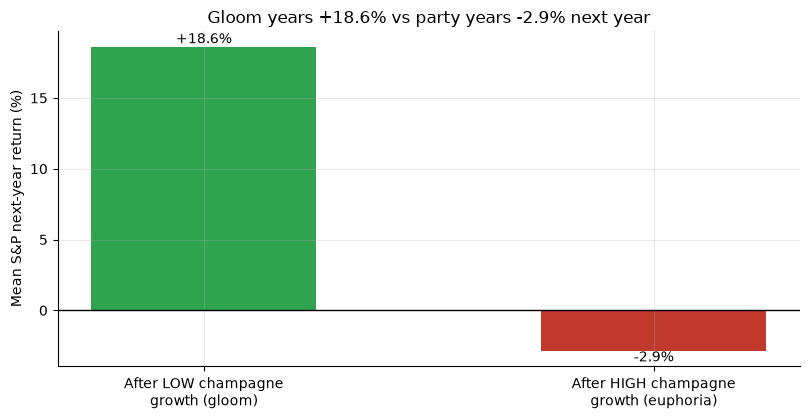

Low-growth (gloom) years next-year return:  +18.6%
High-growth (party) years next-year return: -2.9%
Spread (gloom minus party): +21.5pp


In [4]:
if real_tape:
    terc = st.tercile_spread(df)
    lo_m = terc['mean_ret_low_growth']*100
    hi_m = terc['mean_ret_high_growth']*100
else:
    lo_m, hi_m = R['mean_ret_low_pct'], R['mean_ret_high_pct']

fig, ax = plt.subplots(figsize=(8.2, 4.3))
bars = ax.bar(['After LOW champagne\ngrowth (gloom)',
               'After HIGH champagne\ngrowth (euphoria)'],
              [lo_m, hi_m], color=[GREEN, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean S&P next-year return (%)')
ax.set_title(f'Gloom years +{lo_m:.1f}% vs party years {hi_m:+.1f}% next year')
for b, v in zip(bars, [lo_m, hi_m]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'Low-growth (gloom) years next-year return:  {lo_m:+.1f}%')
print(f'High-growth (party) years next-year return: {hi_m:+.1f}%')
print(f'Spread (gloom minus party): {lo_m-hi_m:+.1f}pp')

The contrarian split looks dramatic -- after the gloomiest champagne years the market averaged a strong rebound, after the party years it stalled. That **+21.5pp** gap is the kind of number that sells newsletters. The quants' notebook shows it is powered by a few extreme years (2008, 2020 on the gloom side; 2007, 2021 on the party side) and is not robust once you account for the tiny sample.

## 5 - The verdict

- **Signal -- Weak.** The relationship points the folklore way (corr **-0.33**, slope negative) and is sign-stable to leaving any single year out -- but the robust HAC t-stat is only **-1.30**, short of the |t| = 2 bar. Literature and direction support it; the statistics do not confirm it. That is a **Weak** signal, not a real one.
- **Tradability -- Mirage.** The long/short overlay nets **+4.7%/yr** against **+6.8%/yr** for buy-and-hold. Shorting equities in 'party' years fights their upward drift, and the borrow + costs eat the rest.
- **Mostly busted.** The marquee hits (2007->2008, 2021->2022) are real, but n = 25 and a couple of dominant years are how spurious-looking patterns are born.

## 6 - Could you actually trade it?

The strategy: go long the S&P after below-median champagne growth, short after above-median growth. The catch is that you spend years *short* a market that goes up most of the time.

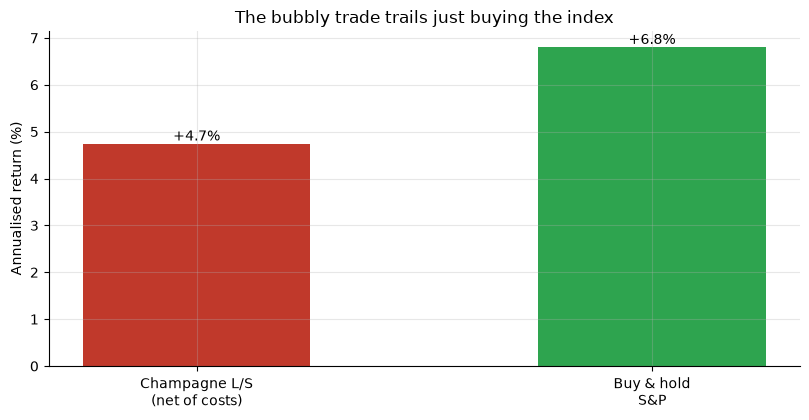

Champagne long/short, net: +4.7%/yr
Buy and hold S&P:          +6.8%/yr
Shortfall:                 -2.1pp/yr
(^GSPC is price-only; total return would lift buy-and-hold further.)


In [5]:
if real_tape:
    bt = st.backtest_long_short(df, cost_bps=10.0, borrow_bps=50.0)
    net, gross, bah = bt['net_ann']*100, bt['gross_ann']*100, bt['bah_ann']*100
else:
    net, gross, bah = R['net_ann_pct'], R['gross_ann_pct'], R['bah_ann_pct']

fig, ax = plt.subplots(figsize=(8.2, 4.3))
bars = ax.bar(['Champagne L/S\n(net of costs)', 'Buy & hold\nS&P'],
              [net, bah], color=[RED, GREEN], width=0.5)
ax.set_ylabel('Annualised return (%)')
ax.set_title('The bubbly trade trails just buying the index')
for b, v in zip(bars, [net, bah]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Champagne long/short, net: {net:+.1f}%/yr')
print(f'Buy and hold S&P:          {bah:+.1f}%/yr')
print(f'Shortfall:                 {net-bah:+.1f}pp/yr')
print('(^GSPC is price-only; total return would lift buy-and-hold further.)')

Even gross of costs the overlay barely matches the index, and net of borrow + trading costs it falls behind. There is no free champagne.

## 7 - Going further

- **The positive control:** the companion notebook plants a real champagne->equity link in a synthetic tape and shows the machinery *does* detect it once n and the effect are big enough. The real tape is below that threshold.
- **Same family of sentiment folklore:** the Hemline Index, the Skyscraper Curse, and the Magazine-Cover Indicator all share this 'euphoria marks the top' structure and the same tiny-n curse.

*Think the corks really do call the top? Fork this, swap in a longer or finer champagne series, and show a predictive slope with HAC |t| >= 2. That's the bar -- and the bubbly hasn't cleared it yet.*